In [2]:
import pandas as pd
import numpy as np
data=pd.read_csv('chip_test.csv')
data.head()

,test1,test2,pass
0,-0.250920,0.414477,1
1,0.901429,-0.694922,0
2,0.463988,0.152577,1
3,0.197317,0.213430,1
4,-0.687963,-0.151739,0


In [3]:
mask=data.loc[:,'pass']==1
print(mask)

0       True
1      False
2       True
3       True
4      False
       ...  
795    False
796    False
797    False
798    False
799    False
Name: pass, Length: 800, dtype: bool


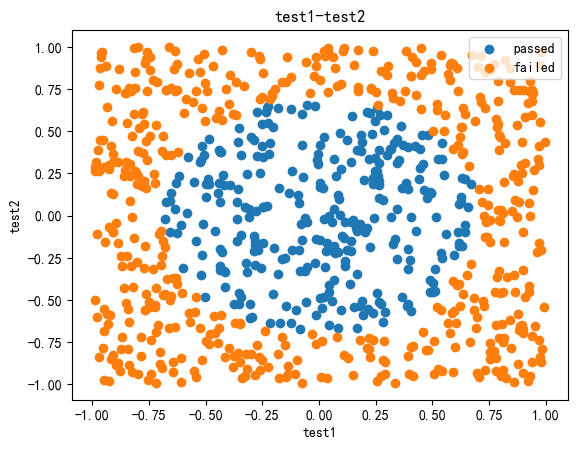

In [4]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure()
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('test1-test2') 
plt.xlabel('test1') 
plt.ylabel('test2')
plt.legend((passed,failed),('passed','failed'))
plt.show()

In [5]:
X=data.drop(['pass'],axis=1)
y=data.loc[:,'pass']
X1=data.loc[:,'test1']
X2=data.loc[:,'test2']
X1_2=X1*X1
X2_2=X2*X2
X1_X2=X1*X2
X_new= {'X1':X1, 'X2':X2, 'X1_2':X1_2, 'X2_2':X2_2, 'X1_X2':X1_X2}
X_new=pd.DataFrame(X_new)
print(X_new)

           X1        X2      X1_2      X2_2     X1_X2
0   -0.250920  0.414477  0.062961  0.171791 -0.104001
1    0.901429 -0.694922  0.812574  0.482916 -0.626422
2    0.463988  0.152577  0.215285  0.023280  0.070794
3    0.197317  0.213430  0.038934  0.045552  0.042113
4   -0.687963 -0.151739  0.473293  0.023025  0.104391
..        ...       ...       ...       ...       ...
795  0.744248  0.156774  0.553905  0.024578  0.116679
796  0.864237 -0.451679  0.746905  0.204014 -0.390357
797  0.130266 -0.841161  0.016969  0.707552 -0.109575
798  0.393302 -0.828684  0.154686  0.686716 -0.325923
799  0.844999  0.788382  0.714023  0.621546  0.666182

[800 rows x 5 columns]


In [6]:
from sklearn.linear_model import LogisticRegression
LR2=LogisticRegression()
LR2.fit(X_new,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
from sklearn.metrics import accuracy_score
y2_predict=LR2.predict(X_new)
accuracy2=accuracy_score(y,y2_predict)
accuracy2

0.99625

D:\Anaconda3\envs\imooc_ai\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


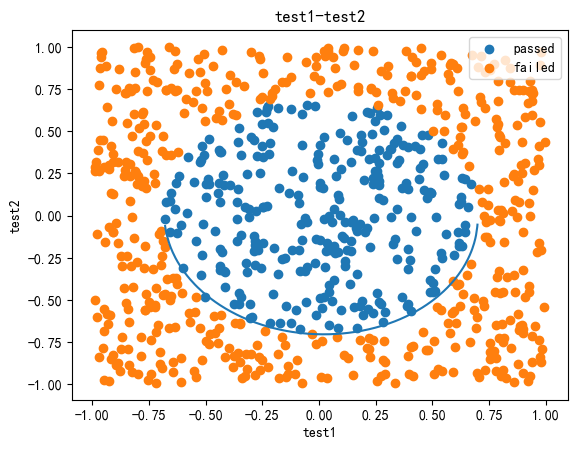

In [8]:
X1_new=X1.sort_values()

theta1,theta2,theta3,theta4,theta5=LR2.coef_[0][0],LR2.coef_[0][1],LR2.coef_[0][2],LR2.coef_[0][3],LR2.coef_[0][4]
theta0=LR2.intercept_
a=theta4
b=theta5*X1_new+theta2
c=theta0+theta1*X1_new+theta3*X1_new*X1_new
X2_new=(-b+np.sqrt(b*b-4*a*c))/(2*a)

fig2=plt.figure()
plt.plot(X1_new,X2_new)
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('test1-test2') 
plt.xlabel('test1') 
plt.ylabel('test2')
plt.legend((passed,failed),('passed','failed'))
plt.show()

In [23]:
#define f(x)
def f(x):
    a=theta4
    b=theta5*x+theta2
    c=theta0+theta1*x+theta3*x*x
    X2_new_boundary1=(-b+np.sqrt(b*b-4*a*c))/(2*a)
    X2_new_boundary2=(-b-np.sqrt(b*b-4*a*c))/(2*a)
    return X2_new_boundary1,X2_new_boundary2

C:\Users\何郑亚\AppData\Local\Temp\ipykernel_3020\889834520.py:6: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary1=(-b+np.sqrt(b*b-4*a*c))/(2*a)
C:\Users\何郑亚\AppData\Local\Temp\ipykernel_3020\889834520.py:7: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary2=(-b-np.sqrt(b*b-4*a*c))/(2*a)


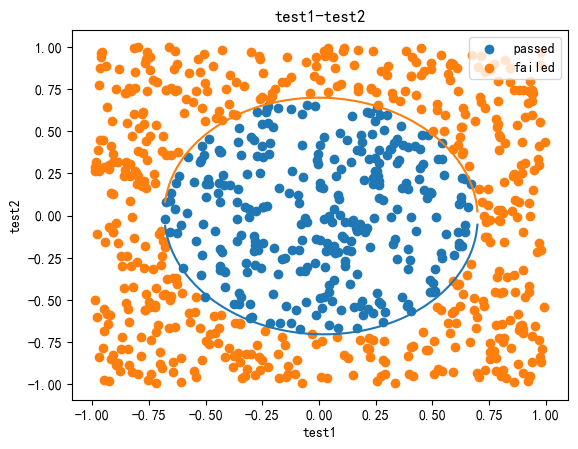

In [24]:
X2_new_boundary1=[]
X2_new_boundary2=[]
for x in X1_new:
    X2_new_boundary1.append(f(x)[0])
    X2_new_boundary2.append(f(x)[1])
fig3=plt.figure()
plt.plot(X1_new,X2_new_boundary1)
plt.plot(X1_new,X2_new_boundary2)
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('test1-test2') 
plt.xlabel('test1') 
plt.ylabel('test2')
plt.legend((passed,failed),('passed','failed'))
plt.show()

In [25]:
X1_range=[-0.9+x/10000 for x in range(0,19000)]
X1_range=np.array(X1_range)
X2_new_boundary1=[]
X2_new_boundary2=[]
for x in X1_range:
    X2_new_boundary1.append(f(x)[0])
    X2_new_boundary2.append(f(x)[1])

C:\Users\何郑亚\AppData\Local\Temp\ipykernel_3020\889834520.py:6: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary1=(-b+np.sqrt(b*b-4*a*c))/(2*a)
C:\Users\何郑亚\AppData\Local\Temp\ipykernel_3020\889834520.py:7: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary2=(-b-np.sqrt(b*b-4*a*c))/(2*a)


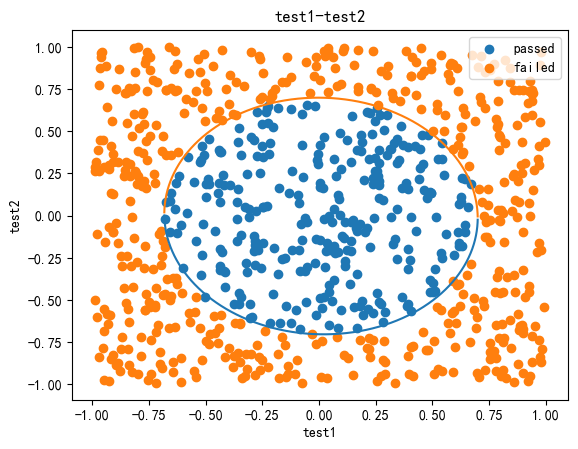

In [27]:
fig4=plt.figure()
plt.plot(X1_range,X2_new_boundary1)
plt.plot(X1_range,X2_new_boundary2)
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('test1-test2') 
plt.xlabel('test1') 
plt.ylabel('test2')
plt.legend((passed,failed),('passed','failed'))
plt.show()